In [1]:
# setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we use regularized linear models
from sklearn.linear_model import Ridge, Lasso, LinearRegression

# for train/test or CV
from sklearn.model_selection import train_test_split as tts

# for scaling
from sklearn.preprocessing import StandardScaler

# we need some stats methods
from scipy.stats import norm, uniform, beta, gamma, triang, kstest, anderson, shapiro

# Import Data

In [2]:
# we need some data to work with
url = 'https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/concrete.csv?raw=true'
data = pd.read_csv(url)

In [3]:
data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


# Generate some probable errors via regression

In [4]:
x = data.drop(columns='strength').values
y = data['strength'].values

In [5]:
# we want to generate some probable errors via regression
model = Ridge(alpha=0.01)
model.fit(x,y)
errors = y - model.predict(x)

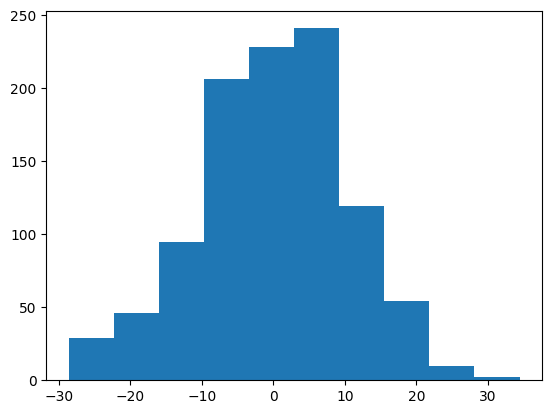

In [6]:
plt.hist(errors)
plt.show()

In [7]:
# useful class for the visualization of frequencies
class distribution_plot:
  def __init__(self,dist,bins=11,hist_color='lightblue',pdf_color='red',fill_region=False,fill_color='lightgreen',fill_bounds=[-1,1],edge_color='k',lw_pdf=2):
    # here we have the instance attributes
    self.dist = dist
    self.bins = bins
    self.hist_color = hist_color
    self.pdf_color = pdf_color
    self.edgecolor = edge_color
    self.lw_pdf = lw_pdf
    self.fill_region = fill_region
    self.fill_color = fill_color
    self.fill_bounds = fill_bounds


  def fit(self,data):
    fig, ax = plt.subplots(figsize=(6, 5))
    # Create the histogram
    sns.histplot(data,
                bins=self.bins,
                kde=False,
                color=self.hist_color,
                alpha=0.5,
                edgecolor=self.edgecolor,
                ax=ax)

    # Calculate the parameters for the normal distribution fit
    params = self.dist.fit(data)

    # Create the x values for the normal distribution curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)

    # Calculate the y values for the normal distribution curve
    p = self.dist.pdf(x, *params)

    # Plot the normal distribution curve, scaling it to the histogram
    # We need to scale it because histplot uses counts, while norm.pdf is a density
    scale_factor = len(data) * (xmax - xmin) / self.bins # Approximate bin width
    ax.plot(x, p * scale_factor, 'r', linewidth=self.lw_pdf)

    ax.set_xlabel('Random Variable', fontsize=16)
    ax.set_ylabel('Frequency', fontsize=16)
    ax.set_title('Data Distribution', fontsize=16)
    if self.fill_region:
      l = ax.lines[0]
      xx = l.get_xydata()[:,0]
      yy = l.get_xydata()[:,1]
      ax.fill_between(xx,yy, where=(self.fill_bounds[0]<=xx) & (xx <= self.fill_bounds[1]), color=self.fill_color,alpha=0.5)
      plt.savefig('example_distribution.png',dpi=300)
    plt.show()

In [8]:
# here we assumed 'val' is only a 1-dim array
def zscore(val):
    return (val-np.mean(val))/np.std(val)

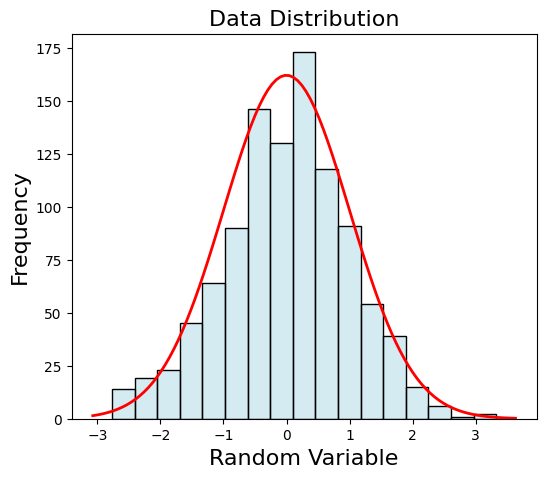

In [9]:
visualize = distribution_plot(norm, bins=17)
visualize.fit(zscore(errors))

# Q-Q plot

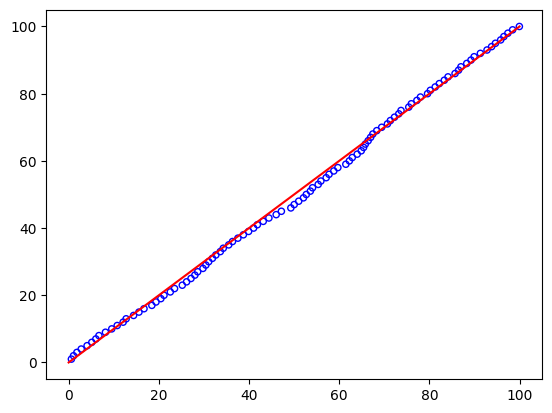

In [10]:
# now we want to create Q-Q plot
percents = np.arange(1,101,1)
# now we compute the empirical percentiles
em_percentiles = np.percentile(zscore(errors),percents)
em_percents = norm.cdf(em_percentiles)
# here below we show the actual plot
plt.scatter(em_percents*100, percents,s=20,marker='o', facecolor='none',edgecolor='blue')
plt.plot([0,100],[0,100],color='red')
plt.show()

# Normality Test

In [11]:
# now we want to apply more detailed normality tests:
# K-S
kstest(zscore(errors),'norm')

KstestResult(statistic=np.float64(0.03381258343368981), pvalue=np.float64(0.18535867595167344), statistic_location=np.float64(-0.010155764581134041), statistic_sign=np.int8(-1))

So, the K-S test is saysing that your errors do not violate the normality assumption since the p-value is quite high such as 18%.

In [12]:
# Anderson-Darling test
anderson(zscore(errors))

AndersonResult(statistic=np.float64(1.23975589763063), critical_values=array([0.574, 0.653, 0.784, 0.914, 1.088]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(0.0), scale=np.float64(1.0004857906528948))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

$A^2 > $ critical value: The Anderson-Darling test is rejecting the normality assumption due to deviations of the emprical quantiles from the theoretical ones at extremmities.

In [13]:
# Shapiro-Wilk
shapiro(zscore(errors))

ShapiroResult(statistic=np.float64(0.9953233247605099), pvalue=np.float64(0.0029925928784472018))

The Shapiro test is saying that the errors are not perfectly normally distributed; however they approximate the normal distribution quite well. Be mindful that p-values are affected by the sample size.

## Split data and redo normality test

In [14]:
# how about we separate the ddeviatgionsata into a train and test, and check the normality of errors on the test set?
xtrain, xtest, ytrain, ytest = tts(x,y, test_size=0.1, shuffle=True)

In [15]:
scale = StandardScaler()
xtrain = scale.fit_transform(xtrain)
xtest = scale.transform(xtest)

In [16]:
model = Ridge(alpha=0.01)
model.fit(xtrain,ytrain)
errors = ytest - model.predict(xtest)

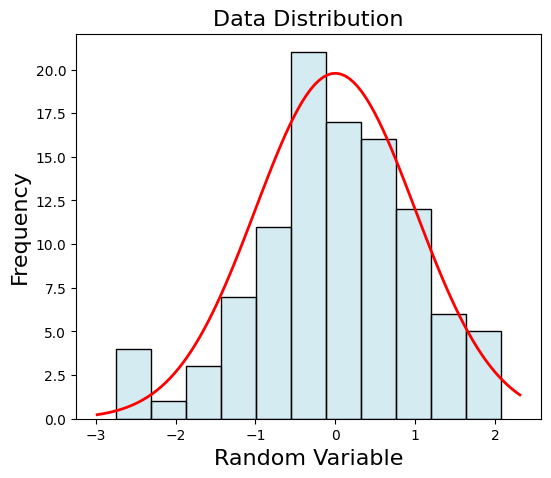

In [17]:
visualize = distribution_plot(norm, bins=11)
visualize.fit(zscore(errors))

In [18]:
kstest(zscore(errors),'norm')

KstestResult(statistic=np.float64(0.06152054581830957), pvalue=np.float64(0.8075244421458175), statistic_location=np.float64(-0.457498282773788), statistic_sign=np.int8(-1))

In [19]:
anderson(zscore(errors))

AndersonResult(statistic=np.float64(0.36342954109103687), critical_values=array([0.556, 0.633, 0.759, 0.886, 1.054]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(1.0239921100911638e-17), scale=np.float64(1.0048900047112757))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

The Anderson test is suggesting that we fail to reject the normality assumption (so data is not violating the normality assumption) since the p-value > 5%

In [20]:
shapiro(zscore(errors))

ShapiroResult(statistic=np.float64(0.9833842011105791), pvalue=np.float64(0.22440575087088394))

So now all three tests are in agreement, and we also demonstrated the samplesize effect on the p-values.

# Demonstrate the Central Limit Theorem

In [21]:
# we create a population that is not normally distributed
# let's simulate a population from a triangular distribution
population = triang.rvs(size=10000,loc=-3, scale=4,c=0.3)

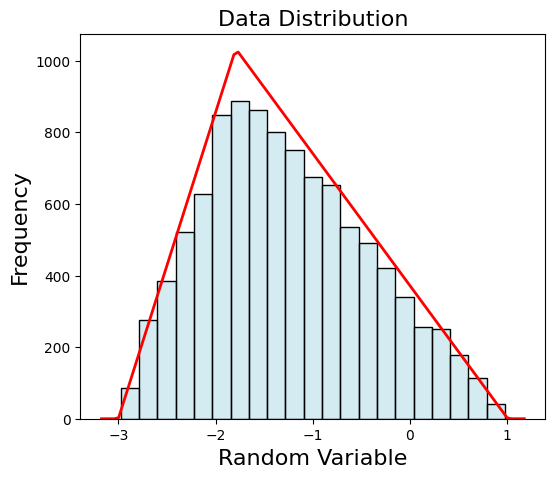

In [22]:
visualize = distribution_plot(triang, bins=21)
visualize.fit(population)

In [23]:
# let's create many sample means
samples = [np.random.choice(population,size=32,replace=False) for _ in range(200)]

In [24]:
means = np.mean(samples, axis=1)

In [25]:
means

array([-1.15567795, -1.05234596, -1.50859278, -1.33990849, -1.26490657,
       -1.35654519, -1.206948  , -1.20992632, -1.44369849, -1.28646955,
       -1.26615966, -1.31883726, -1.3361865 , -1.50886381, -1.4206399 ,
       -0.9867816 , -1.07830796, -1.01059731, -1.21965067, -1.26146603,
       -1.33468217, -1.22345822, -1.06741233, -1.47447036, -1.09797256,
       -1.32865999, -0.9811962 , -1.19590045, -1.33326455, -1.2285675 ,
       -1.39182333, -1.01596743, -1.33988962, -1.37751748, -1.11376058,
       -1.20826557, -1.28955774, -1.51491914, -1.13569699, -1.13255019,
       -1.1673083 , -1.46634666, -1.25092855, -1.18961634, -1.46064074,
       -1.20217942, -1.35133961, -1.11179132, -1.39709756, -1.19043557,
       -1.30560397, -1.31598995, -1.13033799, -1.63389693, -1.25209407,
       -1.30190839, -1.65298466, -1.16060087, -1.11132734, -1.22825609,
       -1.16798963, -1.17623441, -1.52682463, -0.98322204, -1.03560505,
       -1.39785716, -1.15535893, -1.3890661 , -1.29099894, -1.32

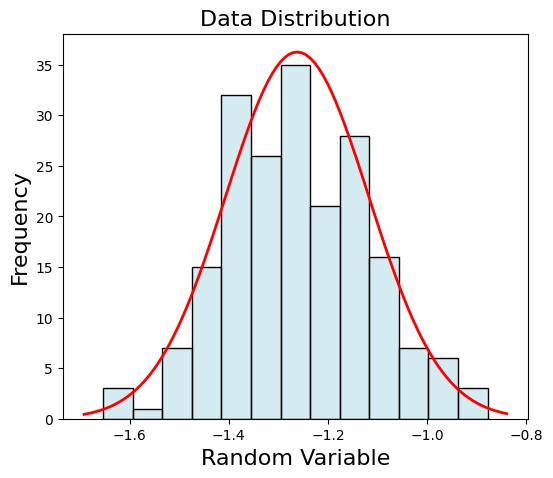

In [26]:
visualize = distribution_plot(norm, bins=13)
visualize.fit(means)

In [27]:
def zscore(val):
    return (val-np.mean(val))/np.std(val)

In [28]:
kstest(zscore(means),'norm')

KstestResult(statistic=np.float64(0.04923795717417501), pvalue=np.float64(0.6983655663730964), statistic_location=np.float64(0.07718557819905227), statistic_sign=np.int8(1))

In [29]:
anderson(zscore(means))

AndersonResult(statistic=np.float64(0.4953509167415291), critical_values=array([0.565, 0.644, 0.772, 0.901, 1.071]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-1.4854784069484595e-15), scale=np.float64(1.002509414234171))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [30]:
shapiro(zscore(means))

ShapiroResult(statistic=np.float64(0.9927870124001599), pvalue=np.float64(0.4330171096378736))

In [31]:
# an example with a beta distribution
population = beta.rvs(size=10000,loc=1, scale=3,a=2.8,b=2.2)

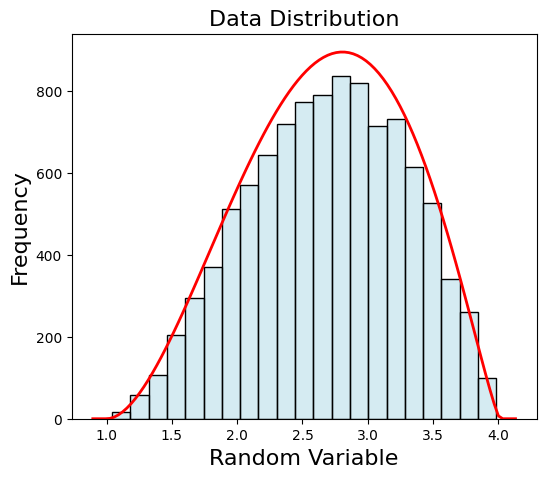

In [32]:
visualize = distribution_plot(beta, bins=21)
visualize.fit(population)

In [33]:
samples = [np.random.choice(population,size=30,replace=True) for _ in range(180)]

In [34]:
means = np.mean(samples, axis=1)

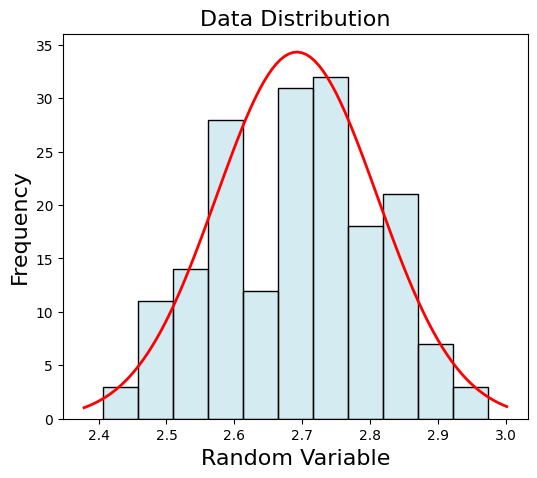

In [35]:
visualize = distribution_plot(norm, bins=11)
visualize.fit(means)

In [36]:
# let's do a q-q plot
percentages = np.arange(1,101,1)

In [37]:
percentages

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [38]:
emp_percentiles = np.percentile(zscore(means),percentages)

In [39]:
emp_percentiles

array([-2.14783954, -1.73976395, -1.70962328, -1.68530999, -1.64134269,
       -1.5789966 , -1.54924448, -1.49699285, -1.35297862, -1.34761024,
       -1.3381626 , -1.3106717 , -1.26305889, -1.18761759, -1.12589849,
       -1.02715616, -1.00508057, -0.97811558, -0.96429001, -0.949378  ,
       -0.91479349, -0.89078516, -0.86056905, -0.84057214, -0.80207363,
       -0.79552734, -0.78494272, -0.75316455, -0.71750968, -0.7065109 ,
       -0.68410427, -0.60143215, -0.48461632, -0.44089912, -0.40119458,
       -0.35484182, -0.27136158, -0.18026682, -0.16876104, -0.16367619,
       -0.14295582, -0.12693287, -0.10906573, -0.09254605, -0.06288785,
       -0.03105679,  0.06943258,  0.10072979,  0.10805606,  0.11572747,
        0.12435812,  0.14178857,  0.18864581,  0.19316492,  0.19617489,
        0.20250994,  0.21584639,  0.24053993,  0.26715025,  0.29599759,
        0.31390135,  0.33158371,  0.35484829,  0.37366891,  0.38785726,
        0.39697966,  0.41213612,  0.43654733,  0.46477127,  0.48

In [40]:
norm.cdf(emp_percentiles)

array([0.01586325, 0.04095024, 0.04366778, 0.04596439, 0.05036315,
       0.05716842, 0.06066148, 0.06719756, 0.08803123, 0.08889189,
       0.09042172, 0.09498435, 0.10328401, 0.11749205, 0.13010424,
       0.15217347, 0.15742903, 0.16400858, 0.16745027, 0.1712142 ,
       0.18015003, 0.18652222, 0.19473772, 0.20029384, 0.21125518,
       0.21315341, 0.21624358, 0.22567552, 0.23652983, 0.23993524,
       0.24695466, 0.27377609, 0.31397427, 0.32964302, 0.34413843,
       0.36135405, 0.39305648, 0.42847155, 0.4329923 , 0.43499303,
       0.44316254, 0.44949676, 0.45657518, 0.4631321 , 0.47492791,
       0.48761212, 0.52767735, 0.54011752, 0.54302439, 0.54606573,
       0.54948413, 0.5563765 , 0.57481479, 0.57658509, 0.57776336,
       0.58024095, 0.58544626, 0.59504415, 0.60532326, 0.61638404,
       0.62320202, 0.62989819, 0.63864838, 0.64567467, 0.65093917,
       0.65430877, 0.65988017, 0.66878016, 0.67895237, 0.68786558,
       0.69066676, 0.72319894, 0.7358881 , 0.7678785 , 0.79844

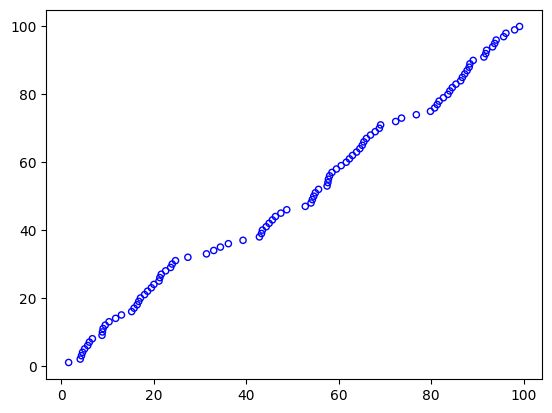

In [41]:
plt.scatter(norm.cdf(emp_percentiles)*100, percentages,s=20, facecolor='none',edgecolor='blue')

In [42]:
# we have to get re-assurance by applying the normality tests
from scipy.stats import kstest, anderson, shapiro

In [43]:
kstest(zscore(means),'norm')

KstestResult(statistic=np.float64(0.06856040047943446), pvalue=np.float64(0.34999940302547106), statistic_location=np.float64(-0.6981211676418148), statistic_sign=np.int8(1))

In [44]:
anderson(zscore(means))

AndersonResult(statistic=np.float64(0.8762122422533025), critical_values=array([0.564, 0.642, 0.77 , 0.899, 1.069]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-4.194175870806147e-16), scale=np.float64(1.0027894056973135))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [45]:
shapiro(zscore(means))

ShapiroResult(statistic=np.float64(0.9856808033489918), pvalue=np.float64(0.0632876381168366))